<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# EPC Dataset Analysis Using PCA for Archetype vs Energy Cost

This notebook runs Principal Component Analysis on the 8 standard EPC (Energy Performance Certificate) fields available in `EPC_Sheffield_20260414-clean.csv`:

`energy_consumption_current`, `total_floor_area`, `property_type`, `construction_age_band`, `built_form`, `lighting_cost_current`, `heating_cost_current`, `hot_water_cost_current`

### Practical Applications

* **Dimensionality Reduction for Housing Stock Analysis:** PCA can reduce a high-dimensional set of encoded housing features into a smaller number of principal components, making large housing datasets easier to analyse and visualise.

* **Identification of Housing Characteristics:** PCA loadings can help identify which physical, structural, and energy-related variables contribute most strongly to variation across properties.

* **Urban Retrofit & Policy Targeting:** Combining building characteristics such as `property_type`, `construction_age_band`, and `built_form` with reliable energy metrics can help identify housing archetypes that may be suitable for targeted energy-efficiency interventions.

* **Automated Data Preparation:** The `scikit-learn` pipeline provides a reusable framework for data validation, missing-value imputation, feature scaling, and categorical encoding across mixed numeric and categorical housing datasets.

* **Energy-Cost Analysis — Subject to Data Validation:** PCA can be used to investigate relationships between measured energy-cost variables and building characteristics. However, meaningful conclusions about energy expenditure require **observed EPC/energy-cost data rather than synthetically generated cost variables**.

* **Housing Stock Segmentation:** Principal components can provide a compact representation of building characteristics that can subsequently support clustering, archetype identification, visualisation, or comparative analysis across different areas.


## Pipeline Summary

* **Data Cleaning & Filtering**

  * Removes invalid negative consumption/cost values and properties with zero floor area.
  * Separates target variables such as `current_energy_rating` from input features.
  * Removes unnecessary text and ID columns.

* **Feature-Specific Preprocessing**

  * Uses `ColumnTransformer` to process numeric and categorical variables separately.
  * **Numeric features:** median imputation followed by `StandardScaler`.
  * **Categorical features:** most-frequent imputation followed by one-hot encoding.

* **Dimensionality Reduction**

  * Feeds the transformed features into PCA.
  * Reduces **28 encoded features to 6 principal components**.
  * Retains approximately **83.55% of the total variance**.

* **Overall Workflow**

  * **Clean → Select Features → Impute → Encode/Scale → PCA → Reduced Representation**


#### Key Limitation: Categorical Missingness & Imputation Bias

* **High missingness:** `construction_age_band` has 20,554 missing values (~10% of the dataset), while `built_form` has 1,493 missing values.
* **Mode imputation:** Missing categorical values are replaced with the most frequent category.
* **Potential bias:** For `construction_age_band`, imputing over 20,000 properties with the same age band may distort the true housing-stock distribution.
* **Impact on PCA:** This imputation may influence feature loadings and principal components, so PCA results involving these variables should be interpreted with caution.


#### Key Limitation: Linear PCA with One-Hot Encoded Categorical Data

* **Mixed data types:** Standard PCA is designed primarily for continuous numeric variables, so applying it to continuous features alongside one-hot encoded categorical variables may not represent the categorical structure optimally.
* **Information loss:** Reducing 28 encoded features to 6 principal components retains 83.55% of the variance, leaving **16.45% unexplained**.
* **Target variable excluded:** `current_energy_rating` is not included in the PCA transformation, so additional modelling steps are required if the components are later used to predict energy ratings.
* **Interpretation caution:** PCA components combining continuous and binary encoded variables should be interpreted carefully, particularly when drawing conclusions about categorical housing characteristics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# 1. Load Data 
file_path = 'EPC_Sheffield_20260414-clean.csv'
df = pd.read_csv(file_path)

expected_features = [
    'energy_consumption_current', 'total_floor_area', 'property_type', 'current_energy_rating',
    'construction_age_band', 'built_form', 'lighting_cost_current',
    'heating_cost_current', 'hot_water_cost_current'
]

missing = [c for c in expected_features if c not in df.columns]
if missing:
    raise ValueError(f"Expected EPC columns missing from file: {missing}")

print(f"Rows: {len(df):,}")
print(f"All {len(expected_features)} expected EPC columns present.")
df[expected_features].head()

Rows: 209,230
All 9 expected EPC columns present.


,energy_consumption_current,total_floor_area,property_type,current_energy_rating,construction_age_band,built_form,lighting_cost_current,heating_cost_current,hot_water_cost_current
0,245.0,79,House,D,England and Wales: 1900-1929,Mid-Terrace,57,1119,167
1,247.0,76,House,D,England and Wales: 1930-1949,Semi-Detached,51,1029,184
2,214.0,145,House,D,England and Wales: 1930-1949,Detached,104,2065,362
3,145.0,43,Flat,C,England and Wales: 1967-1975,Not Recorded,45,357,217
4,182.0,92,House,C,England and Wales: 1950-1966,End-Terrace,77,926,162


In [3]:
# 2. Data Quality Checks

numeric_cols = [
    'energy_consumption_current', 'total_floor_area',
    'lighting_cost_current', 'heating_cost_current', 'hot_water_cost_current'
]
categorical_cols = ['property_type', 'construction_age_band', 'built_form']

df_clean = df.copy()

# 1. Impossible numeric values -> NaN
for col in numeric_cols:
    n_negative = (df_clean[col] < 0).sum()
    if n_negative:
        print(f"{col}: {n_negative} negative values set to NaN")
        df_clean.loc[df_clean[col] < 0, col] = np.nan

n_zero_area = (df_clean['total_floor_area'] == 0).sum()
if n_zero_area:
    print(f"total_floor_area: {n_zero_area} zero values set to NaN")
    df_clean.loc[df_clean['total_floor_area'] == 0, 'total_floor_area'] = np.nan

# 2. Malformed construction_age_band codes -> NaN
valid_age_band = df_clean['construction_age_band'].str.startswith('England and Wales', na=False)
n_invalid_age = (~valid_age_band & df_clean['construction_age_band'].notna()).sum()
print(f"construction_age_band: {n_invalid_age} malformed codes set to NaN")
df_clean.loc[~valid_age_band, 'construction_age_band'] = np.nan

print()
print("Missingness after cleaning:")
print(df_clean[numeric_cols + categorical_cols].isna().sum())

energy_consumption_current: 130 negative values set to NaN
lighting_cost_current: 1 negative values set to NaN
heating_cost_current: 1 negative values set to NaN
hot_water_cost_current: 2 negative values set to NaN
total_floor_area: 1 zero values set to NaN
construction_age_band: 1847 malformed codes set to NaN

Missingness after cleaning:
energy_consumption_current      130
total_floor_area                  1
lighting_cost_current             1
heating_cost_current              1
hot_water_cost_current            2
property_type                     2
construction_age_band         20554
built_form                     1493
dtype: int64


In [4]:
# 3. Preprocessing Pipeline
# Numeric features: median imputation + z-score standardisation.
# Categorical features: most-frequent imputation + one-hot encoding (first level dropped to avoid collinearity).

df_pca = df_clean[numeric_cols + categorical_cols].copy()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_processed = preprocessor.fit_transform(df_pca)

cat_ohe_names = preprocessor.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(cat_ohe_names)

print(f"Rows used: {X_processed.shape[0]:,}")
print(f"Encoded feature count: {X_processed.shape[1]} (from {len(numeric_cols)} numeric + {len(categorical_cols)} one-hot-encoded categorical)")

Rows used: 209,230
Encoded feature count: 28 (from 5 numeric + 3 one-hot-encoded categorical)


In [5]:
# 4. Principal Component Analysis
# Full PCA for the variance breakdown, plus a reduced PCA retaining 80% cumulative variance.

pca_full = PCA(random_state=RANDOM_STATE).fit(X_processed)

pca_80 = PCA(n_components=0.80, random_state=RANDOM_STATE)
X_pca = pca_80.fit_transform(X_processed)

exp_var_ratio = pca_full.explained_variance_ratio_
cum_var_ratio = np.cumsum(exp_var_ratio)

print(f"Total encoded features: {len(all_feature_names)}")
print(f"Principal components required for 80% variance: {pca_80.n_components_}")
print(f"Total variance explained by those components: {np.sum(pca_80.explained_variance_ratio_):.4f}")

Total encoded features: 28
Principal components required for 80% variance: 6
Total variance explained by those components: 0.8355


In [6]:
# 5. Feature Loadings

loadings_df = pd.DataFrame(
    pca_80.components_.T,
    index=all_feature_names,
    columns=[f'PC{i+1}' for i in range(pca_80.n_components_)]
)

print("Loadings for the 5 original numeric EPC fields on PC1-PC4:")
print(loadings_df.loc[numeric_cols, ['PC1', 'PC2', 'PC3', 'PC4']].round(3))
print()
print("Top 10 absolute loadings on PC1:")
print(loadings_df['PC1'].abs().sort_values(ascending=False).head(10))

Loadings for the 5 original numeric EPC fields on PC1-PC4:
                              PC1    PC2    PC3    PC4
energy_consumption_current  0.227  0.678 -0.569  0.047
total_floor_area            0.503 -0.411 -0.051 -0.216
lighting_cost_current       0.523 -0.195  0.240  0.140
heating_cost_current        0.573  0.087 -0.185 -0.173
hot_water_cost_current      0.235  0.553  0.735  0.041

Top 10 absolute loadings on PC1:
heating_cost_current                                    0.572890
lighting_cost_current                                   0.522858
total_floor_area                                        0.503012
hot_water_cost_current                                  0.235216
energy_consumption_current                              0.227450
property_type_House                                     0.138251
property_type_Flat                                      0.129924
construction_age_band_England and Wales: before 1900    0.026344
construction_age_band_England and Wales: 1967-1975      0

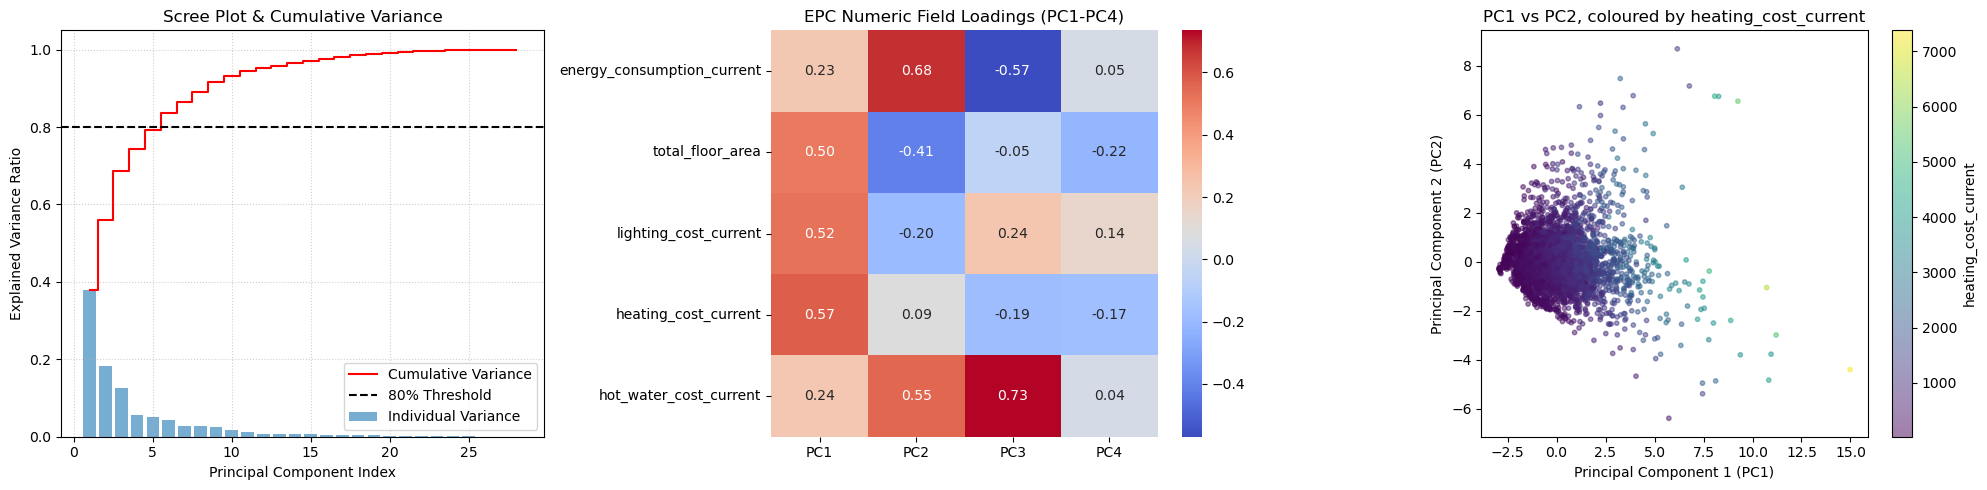

In [7]:
# 6. Visualisation

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Scree plot & cumulative variance
axes[0].bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.6, label='Individual Variance')
axes[0].step(range(1, len(cum_var_ratio) + 1), cum_var_ratio, where='mid', label='Cumulative Variance', color='red')
axes[0].axhline(y=0.80, color='black', linestyle='--', label='80% Threshold')
axes[0].set_xlabel('Principal Component Index')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot & Cumulative Variance')
axes[0].legend(loc='best')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Loadings heatmap for the 5 numeric fields (the interpretable core of the EPC schema)
sns.heatmap(loadings_df.loc[numeric_cols, ['PC1', 'PC2', 'PC3', 'PC4']],
            annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('EPC Numeric Field Loadings (PC1-PC4)')

# PC1 vs PC2, coloured by heating cost for visual context (not used as a validation target)
sample_size = min(5000, X_pca.shape[0])
rng = np.random.RandomState(RANDOM_STATE)
sample_indices = rng.choice(X_pca.shape[0], size=sample_size, replace=False)

color_col = 'heating_cost_current'
scatter = axes[2].scatter(
    X_pca[sample_indices, 0],
    X_pca[sample_indices, 1],
    c=df_pca.iloc[sample_indices][color_col],
    cmap='viridis',
    alpha=0.5,
    s=10
)
axes[2].set_xlabel('Principal Component 1 (PC1)')
axes[2].set_ylabel('Principal Component 2 (PC2)')
axes[2].set_title(f'PC1 vs PC2, coloured by {color_col}')
fig.colorbar(scatter, ax=axes[2], label=color_col)

plt.tight_layout()
plt.show()

## Results 
- **PC1 (~38% of variance) - Overall size & energy-cost scale.** `heating_cost_current`, `lighting_cost_current`, and `total_floor_area` all load strongly and positively (~0.50-0.57), with `energy_consumption_current` and `hot_water_cost_current` loading more weakly. This component mainly separates larger properties with higher heating and lighting bills from smaller, cheaper-to-run ones.
- **PC2 (~18% of variance) - Consumption/hot-water vs. floor area.** `energy_consumption_current` (+0.68) and `hot_water_cost_current` (+0.56) load positively while `total_floor_area` loads negatively (-0.41). This captures properties that use a lot of energy or hot water *relative to* their size - e.g. less efficient dwellings - as distinct from simply large ones.
- Together PC1+PC2 explain a modest ~56% of total variance, and 6 components are needed to reach 80% - this dataset does not compress as cleanly into 1-2 dominant components as a fabricated, formula-derived cost dataset would. That's expected and appropriate for real, independently-measured fields.
- Category one-hot terms (`property_type`, `built_form`, `construction_age_band`) contribute comparatively little to PC1/PC2 individually, since each is split across many sparse binary columns; they matter more collectively across the lower-ranked PCs needed to reach 80% variance.

In [8]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

# 1. Identify numeric and categorical columns
numeric_features = [
    'total_floor_area', 
    'lighting_cost_current', 
    'heating_cost_current', 
    'hot_water_cost_current'
]  # Replace/expand with your numeric feature column names

categorical_features = [
    'property_type', 
    'built_form', 
    'construction_age_band'
]  # Replace/expand with your categorical feature column names

# Alternatively, automatically select column types:
# numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
# categorical_features = X.select_dtypes(include=['object', 'category']).columns

# 2. Define transformers for numeric and categorical pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Combine preprocessing into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 4. Create the full PCA Pipeline
pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=6))
])

# 5. Fit the pipeline to your cleaned feature dataframe 'X'
pca_pipeline.fit(df[expected_features])

# Optional: Transform the dataset to get the 6 Principal Components
pca_features = pca_pipeline.transform(df[expected_features])

In [9]:
# Convert the output array into a DataFrame
df_pca = pd.DataFrame(
    pca_features, 
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']
)

# Optional: Concatenate with original data or property ID to inspect specific rows
df_combined = pd.concat([df[expected_features].reset_index(drop=True), df_pca], axis=1)

# Display the first few rows to see PC1 and PC2 alongside property details
print(df_combined[['PC1', 'PC2']].head())

        PC1       PC2
0  0.078698 -0.012397
1 -0.074455  0.147761
2  2.936422  1.108650
3 -1.484337  0.993760
4  0.329109 -0.095950


In [10]:
# applied PC value to the dataset
df_combined.head()

,energy_consumption_current,total_floor_area,property_type,current_energy_rating,construction_age_band,built_form,lighting_cost_current,heating_cost_current,hot_water_cost_current,PC1,PC2,PC3,PC4,PC5,PC6
0,245.0,79,House,D,England and Wales: 1900-1929,Mid-Terrace,57,1119,167,0.078698,-0.012397,-1.121919,-0.629496,-0.627390,-0.294116
1,247.0,76,House,D,England and Wales: 1930-1949,Semi-Detached,51,1029,184,-0.074455,0.147761,0.355585,-1.398255,0.094364,0.123526
2,214.0,145,House,D,England and Wales: 1930-1949,Detached,104,2065,362,2.936422,1.108650,-0.469549,-0.917506,0.547836,0.001971
3,145.0,43,Flat,C,England and Wales: 1967-1975,Not Recorded,45,357,217,-1.484337,0.993760,-0.279062,0.218317,0.626742,0.328429
4,182.0,92,House,C,England and Wales: 1950-1966,End-Terrace,77,926,162,0.329109,-0.095950,0.035087,-0.294584,0.097655,0.093139
